In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = [ "linear_regression", "random_forest", "svr"] 
# models = ["linear_regression", "decision_tree", "random_forest", "svr"]
all_results = []

for model in models:
    with open(f"../results/{model}_results.json", "r") as f:
        all_results.append(json.load(f))

df_results = pd.DataFrame(all_results)
df_results = df_results.set_index("model")

print(df_results)

                   RMSE      R2
model                          
random_forest  31594.17  0.8699
svr            26116.27  0.9111


In [ ]:
print("=" * 45)
print(f"{'Model':<25} {'RMSE':>10} {'R² Score':>10}")
print("=" * 45)

for model, row in df_results.iterrows():
    print(f"{model:<25} {row['RMSE']:>10.2f} {row['R2']:>10.4f}")

print("=" * 45)

Model                           RMSE   R² Score
random_forest               31594.17     0.8699
svr                         26116.27     0.9111


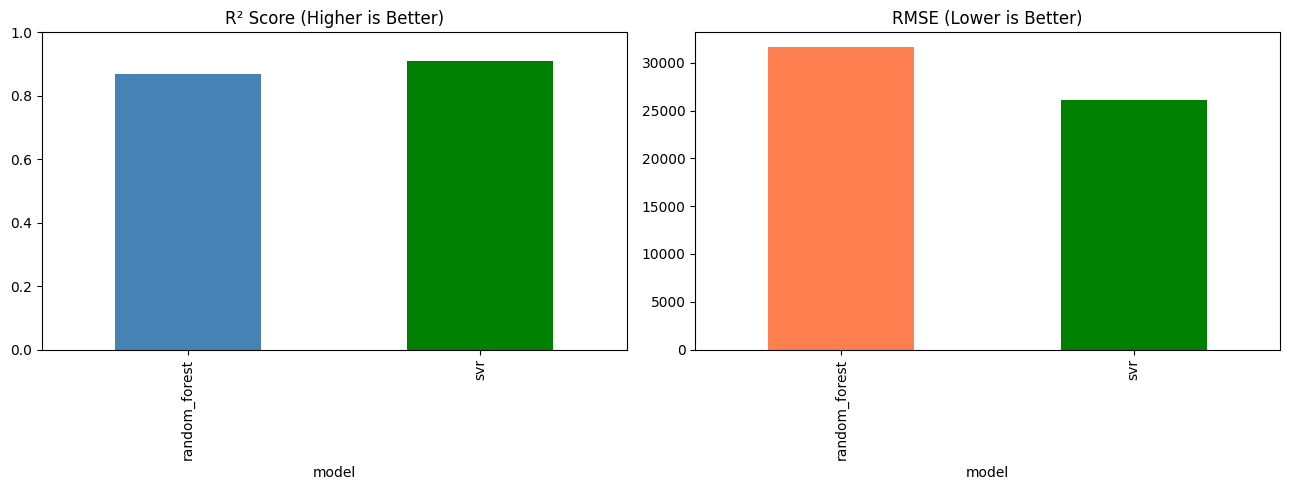

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R² (higher is better)
colors_r2 = ['green' if v == df_results['R2'].max() else 'steelblue' for v in df_results['R2']]
df_results['R2'].plot(kind='bar', ax=axes[0], color=colors_r2)
axes[0].set_title('R² Score (Higher is Better)')
axes[0].set_ylim(0, 1)

# RMSE (lower is better)
colors_rmse = ['green' if v == df_results['RMSE'].min() else 'coral' for v in df_results['RMSE']]
df_results['RMSE'].plot(kind='bar', ax=axes[1], color=colors_rmse)
axes[1].set_title('RMSE (Lower is Better)')

plt.tight_layout()
plt.savefig('../results/comparison_chart.png', dpi=150)
plt.show()

In [ ]:
best_r2 = df_results['R2'].idxmax()
best_rmse = df_results['RMSE'].idxmin()

print(f" Best R² Score : {best_r2} ({df_results.loc[best_r2, 'R2']:.4f})")
print(f" Lowest RMSE   : {best_rmse} ({df_results.loc[best_rmse, 'RMSE']:.2f})")

 Best R² Score : svr (0.9111)
 Lowest RMSE   : svr (26116.27)
